# PatchTST — Walmart Store Sales Forecasting
*Model 3 of 5 · patch Transformer (global, univariate) · experiment-driven*

Five-model comparison (XGBoost, LightGBM, **PatchTST**, DLinear, Prophet) on one
shared 8-week holdout, WMAE with 5× holiday weight. This notebook is built for
**trial-and-error**: one `run_trial(cfg)`, a tracker that shows only what changed.

## 0 · Setup — attach the two utility scripts

Add both via *Notebook → File → Add utility script*:

1. **`preprocessor`** — your existing preprocessor. We reuse only its lightweight,
   contract-defining pieces (`merge_and_preprocess`, `make_masks`, `clean_target`)
   so this model sees the **exact same** split and target cleaning as your trees.
2. **`walmart_ts_common`** — shared TS infrastructure *and* the experiment
   tracker (`build_panel`, `SeriesStore`, `score_val_predictions`,
   `wmae_breakdown`, `ExperimentTracker`, `build_submission`).

Also attach the competition data (*+ Add Input →* the competition).

In [1]:
import sys, glob, time
for p in glob.glob("/kaggle/usr/lib/*") + glob.glob("/kaggle/input/*"):
    if p not in sys.path:
        sys.path.append(p)
sys.path.append("/kaggle/input/datasets/ldavi22/prophet/")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import walmart_ts_common as C

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_DATAPARALLEL = False        # flip on to split each batch across 2x T4
print("torch", torch.__version__, "| device:", DEVICE, "| GPUs:", torch.cuda.device_count())

torch 2.10.0+cu128 | device: cuda | GPUs: 2


## 0b · MLflow / DagsHub logging

Every trial is mirrored to **your** DagsHub-backed MLflow: params = the `cfg`, metrics = `val_wmae` plus the holiday / non-holiday split. A final `*_Best` run (in §6) logs the submission, the trained model, and the experiment log as artifacts.


In [2]:
!pip install dagshub "mlflow>=2.22.0" -q

DAGSHUB_OWNER = "nikaduri"                           # <-- your DagsHub username
DAGSHUB_REPO  = "ml-store-sales-forecasting"   # <-- your DagsHub repo (create once)
MLFLOW_EXPERIMENT = "PatchTST_Training"

_token = None
try:                                                 # Kaggle Secrets (preferred)
    from kaggle_secrets import UserSecretsClient
    _token = UserSecretsClient().get_secret("DAGSHUB_TOKEN")
except Exception:
    _token = None                                    # -> dagshub OAuth fallback

C.setup_dagshub_mlflow(DAGSHUB_OWNER, DAGSHUB_REPO, token=_token)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 101.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 83.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=08bce598-6815-468c-984e-862ab35631d5&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=e655a635b610b2ce48fe9e82e2967c150c8371b3288b87de442eab9500e72506




Accessing as ldavi22

Initialized MLflow to track repo "nikaduri/ml-store-sales-forecasting"

Repository nikaduri/ml-store-sales-forecasting initialized!

MLflow -> https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow  (auth: oauth)


'https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow'

## 1 · Build the canonical panel (the shared contract)

`build_panel()` calls **your** `preprocessor.py`: identical **last-8-weeks**
split (`make_masks`) and identical target cleaning (`clean_target` — train region
IQR-clipped, val region kept true). WMAE uses a 5× holiday weight, matching the
preprocessor's `w_val`. Every model in the comparison is scored on these same 8
weeks, so any WMAE difference is the model, not the pipeline.

In [3]:
panel = C.build_panel()
store = C.SeriesStore(panel)
print(f"series: {len(store.series):,} | val weeks: {store.n_val} | test weeks: {len(store.test_dates)}")

series: 3,331 | val weeks: 8 | test weeks: 39


## 2 · Windowing — one global, channel-independent dataset

**Global, not per-series:** each series has only ~140 weekly points, so we slice
every series into univariate `(input_len → pred_len)` windows and pool them into
one model. Pooling learns shared seasonality/holiday structure; univariate
slicing keeps it channel-independent (series never mix within a sample).

Baked into `make_training_windows`: `pred_len = 8` (= the val horizon, so the
model trains for exactly what it's scored on); **per-series train-region
normalization** (leak-free, and per Store-Dept because store scales differ
wildly); and **no leakage / no fabricated targets** (a window is kept only if its
whole target is in the train region and originally observed; short input gaps are
interpolated on a regular weekly grid).

`input_len` is a **hyperparameter** below — bigger lookback sees more seasonality
but disqualifies short series (watch `n_fallback` move).

## 3 · Model definition

In [4]:
class PatchTST(nn.Module):
    def __init__(self, input_len, pred_len, patch_len=13, stride=13,
                 d_model=128, n_heads=8, depth=3, d_ff=256, dropout=0.1):
        super().__init__()
        self.patch_len, self.stride = patch_len, stride
        self.pad = (stride - (input_len - patch_len) % stride) % stride
        n_patches = (input_len + self.pad - patch_len) // stride + 1
        self.embed = nn.Linear(patch_len, d_model)
        self.pos   = nn.Parameter(torch.randn(1, n_patches, d_model) * 0.02)
        enc = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads,
                dim_feedforward=d_ff, dropout=dropout, batch_first=True,
                activation="gelu")
        self.encoder = nn.TransformerEncoder(enc, num_layers=depth)
        self.head = nn.Sequential(nn.Flatten(),
                                  nn.Linear(n_patches * d_model, pred_len))
    def forward(self, x):
        if self.pad:
            x = torch.cat([x, x[:, -1:].repeat(1, self.pad)], dim=1)
        patches = x.unfold(1, self.patch_len, self.stride)
        z = self.embed(patches) + self.pos
        z = self.encoder(z)
        return self.head(z)

def build_model(cfg, pred_len=None):
    return PatchTST(cfg["input_len"], pred_len or cfg["pred_len"],
                    patch_len=cfg["patch_len"], stride=cfg["stride"],
                    d_model=cfg["d_model"], n_heads=cfg["n_heads"],
                    depth=cfg["depth"], d_ff=cfg["d_ff"], dropout=cfg["dropout"])

In [5]:
_wmeta, _vcache, _vtcache = {}, {}, {}
def get_windows_meta(L, H):
    if (L, H) not in _wmeta:
        _wmeta[(L, H)] = store.make_training_windows(L, H, return_meta=True)
    return _wmeta[(L, H)]
def get_windows(L, H):
    X, Y, *_ = get_windows_meta(L, H); return X, Y
def get_val_inputs(L):
    if L not in _vcache: _vcache[L] = store.make_val_inputs(L)
    return _vcache[L]
def get_val_targets(L, keys):
    if L not in _vtcache: _vtcache[L] = store.make_val_targets(keys)
    return _vtcache[L]

def set_seed(s):
    np.random.seed(s); torch.manual_seed(s)

def _val_loss(model, Xv_t, Yv_t, Mv_t):
    # normalized L1 on observed val weeks -> same units as the train loss,
    # so train_loss vs val_loss per epoch is a real overfitting curve
    with torch.no_grad():
        diff = (model(Xv_t) - Yv_t).abs() * Mv_t
    return float(diff.sum().item() / Mv_t.sum().clamp(min=1).item())

def train_torch(model, X, Y, lr, epochs, batch_size, val=None):
    model = model.to(DEVICE)
    if USE_DATAPARALLEL and torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(torch.tensor(X), torch.tensor(Y)),
                        batch_size=batch_size, shuffle=True)
    Xv_t = Yv_t = Mv_t = None
    if val is not None:
        Xv, Yv, Mv = val
        Xv_t, Yv_t, Mv_t = (torch.tensor(a).to(DEVICE) for a in (Xv, Yv, Mv))
    history = []
    for ep in range(epochs):
        model.train(); running, nb = 0.0, 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = nn.functional.l1_loss(model(xb), yb)   # MAE aligns with WMAE
            loss.backward(); opt.step()
            running += loss.item(); nb += 1
        row = {"epoch": ep, "train_loss": running / max(nb, 1)}
        if val is not None:
            model.eval(); row["val_loss"] = _val_loss(model, Xv_t, Yv_t, Mv_t)
        history.append(row)
    return model, history

def _predict(model, Xarr, bs=8192):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(Xarr), bs):
            out.append(model(torch.tensor(Xarr[i:i + bs]).to(DEVICE)).cpu().numpy())
    return np.concatenate(out, 0) if out else np.empty((0, 0), np.float32)

TRIAL_CFGS = {}
def run_trial(cfg, tracker=None, note="", return_predictions=False):
    set_seed(cfg["seed"])
    L, H = cfg["input_len"], cfg["pred_len"]
    X, Y = get_windows(L, H)
    Xv, keys, mus, sds = get_val_inputs(L)
    Yv_norm, Mv = get_val_targets(L, keys)

    t0 = time.time()
    model, history = train_torch(build_model(cfg), X, Y, cfg["lr"], cfg["epochs"],
                                 cfg["batch_size"], val=(Xv, Yv_norm, Mv))
    secs = time.time() - t0

    # ---- validation metrics (dollars, via the shared scorer) ----
    pv = _predict(model, Xv)
    pbk = {k: pv[i] * sds[i] + mus[i] for i, k in enumerate(keys)}
    n_model = len(pbk)
    for k in store.series:
        pbk.setdefault(k, store.naive_val(k))
    _, merged = C.score_val_predictions(panel, store, pbk)
    val_m = C.regression_metrics(merged["y_true"], merged["y_pred"],
                                 merged["IsHoliday"], prefix="val_")

    # ---- training metrics (dollars, over the training windows) ----
    Xt, Yt, tmus, tsds, thol = get_windows_meta(L, H)
    pt = _predict(model, Xt)
    tr_pred = pt * tsds[:, None] + tmus[:, None]
    tr_true = Yt * tsds[:, None] + tmus[:, None]
    train_m = C.regression_metrics(tr_true, tr_pred, thol, prefix="train_")

    metrics = {
        "train_mae":  train_m["train_mae"],  "val_mae":  val_m["val_mae"],
        "train_wmae": train_m["train_wmae"], "val_wmae": val_m["val_wmae"],
        "val_rmse":   val_m["val_rmse"],     "val_r2":   val_m["val_r2"],
        "n_fallback": len(store.series) - n_model,
        "train_secs": round(secs, 1),
        "n_params":   sum(p.numel() for p in build_model(cfg).parameters()),
    }
    if tracker is not None:
        tid = tracker.log(cfg, metrics, note, history=history)
        TRIAL_CFGS[tid] = dict(cfg)
    if return_predictions:
        return metrics, merged
    return metrics

## 4 · Run the experiments

### PatchTST — patch-based Transformer

The 52-week window is cut into patches, each embedded like a token; a small
Transformer encoder attends over them; a linear head maps to the 8-week forecast.
Patching gives each token local context and shortens the attention sequence.
RevIN isn't needed inside the model — the per-series normalization already
removes level/scale, leak-free.

Hyperparameters worth trialing: `patch_len`/`stride` (patch granularity),
`d_model`, `depth`, `n_heads`, `dropout`, `input_len`, `lr`.

In [6]:
BASE = dict(input_len=52, pred_len=8, epochs=40, lr=1e-3, batch_size=512, seed=42,
            patch_len=13, stride=13, d_model=128, n_heads=8, depth=3,
            d_ff=256, dropout=0.1)

tracker = C.ExperimentTracker("patchtst", mlflow_experiment=MLFLOW_EXPERIMENT)
run_trial(BASE,                                     tracker, note="baseline")

# -- capacity: depth then width (does a bigger model help or just overfit ~140-pt series?) --
run_trial({**BASE, "depth": 2},                     tracker, note="shallower (2 layers)")
run_trial({**BASE, "d_model": 64},                  tracker, note="narrower (d_model 64)")
run_trial({**BASE, "d_model": 256},                 tracker, note="wider (d_model 256)")

# -- patch geometry: local context vs. sequence length (patch_len+stride move together) --
run_trial({**BASE, "patch_len": 4,  "stride": 4},   tracker, note="fine patches")
run_trial({**BASE, "patch_len": 26, "stride": 13},  tracker, note="overlapping patches")

# -- regularization & optimization --
run_trial({**BASE, "dropout": 0.2},                 tracker, note="more dropout")
run_trial({**BASE, "lr": 3e-3},                     tracker, note="higher lr")

# -- lookback: more seasonality vs. fewer eligible series (watch n_fallback move) --
run_trial({**BASE, "input_len": 104},               tracker, note="2-year lookback")
run_trial({**BASE, "input_len": 26},                tracker, note="short lookback")

[patchtst] MLflow ON -> experiment 'PatchTST_Training'
🏃 View run patchtst_trial01_baseline at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/2/runs/3e250783e1aa49b283bbe6f716345397
🧪 View experiment at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/2
[patchtst · trial 1] val_wmae=1374.97  <- new best  note='baseline'
🏃 View run patchtst_trial02_shallower_2_layers at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/2/runs/6f5fd0660d254409a238e14952a9a588
🧪 View experiment at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/2
[patchtst · trial 2] val_wmae=1388.49  | best: trial 1 @ 1374.97  note='shallower (2 layers)'
🏃 View run patchtst_trial03_narrower_d_model_64 at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/2/runs/31ecf717a8ad4a7fa5b15aea4df759ed
🧪 View experiment at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#

{'train_mae': 1492.22,
 'val_mae': 1584.04,
 'train_wmae': 1704.55,
 'val_wmae': 1567.02,
 'val_rmse': 3246.42,
 'val_r2': 0.9778,
 'n_fallback': 555,
 'train_secs': 318.3,
 'n_params': 401544}

## 5 · Compare trials

`summary()` is the leaderboard (best WMAE first, only varying knobs shown).
`diff(a, b)` attributes the metric change to the single field you altered.

In [7]:
display(tracker.summary())
best_id = int(tracker.summary().iloc[0]["trial"])
tracker.diff(1, best_id)               # baseline -> current best
tracker.to_csv("/kaggle/working/patchtst_experiments.csv")

,trial,d_model,depth,dropout,input_len,lr,patch_len,stride,train_mae,val_mae,train_wmae,val_wmae,val_rmse,val_r2,n_fallback,train_secs,n_params,note
0,3,64,3,0.1000,52,0.0010,13,13,1094.3000,1342.1600,1129.6600,1347.7000,2788.6100,0.9836,591,231.4000,153160,narrower (d_model 64)
1,7,128,3,0.2000,52,0.0010,13,13,1102.8700,1372.7900,1141.3600,1364.3400,2897.1400,0.9823,591,255.2000,403848,more dropout
2,6,128,3,0.1000,52,0.0010,26,13,1028.7200,1377.7000,1067.0400,1372.8000,2954.3100,0.9816,591,247.8000,404360,overlapping patches
3,1,128,3,0.1000,52,0.0010,13,13,1039.0300,1383.0000,1075.1900,1374.9700,2918.5700,0.9821,591,258.0000,403848,baseline
4,2,128,2,0.1000,52,0.0010,13,13,1083.4900,1396.2800,1122.4700,1388.4900,2895.2900,0.9823,591,192.7000,271368,shallower (2 layers)
5,8,128,3,0.1000,52,0.0030,13,13,1113.2400,1406.6000,1152.2800,1403.9600,2976.4700,0.9813,591,255.3000,403848,higher lr
6,4,256,3,0.1000,52,0.0010,13,13,1023.5500,1419.1700,1059.8300,1416.8200,2995.0300,0.9811,591,345.1000,1200136,wider (d_model 256)
7,5,128,3,0.1000,52,0.0010,4,4,1036.5300,1452.1300,1073.5600,1442.9100,3043.8000,0.9805,591,411.1000,413064,fine patches
8,9,128,3,0.1000,104,0.0010,13,13,799.8400,1519.6300,800.4000,1500.0900,3033.4400,0.9806,653,101.8000,408456,2-year lookback
9,10,128,3,0.1000,26,0.0010,13,13,1492.2200,1584.0400,1704.5500,1567.0200,3246.4200,0.9778,555,318.3000,401544,short lookback


[patchtst] diff  trial 1 ('baseline')  ->  trial 3 ('narrower (d_model 64)')
  config changes:
    d_model                             128  ->  64
  metric changes (trial b - trial a):
    train_mae                     1039.03  ->  1094.3        Δ=+55.27 ▲
    val_mae                        1383.0  ->  1342.16       Δ=-40.84 ▼
    train_wmae                    1075.19  ->  1129.66       Δ=+54.47 ▲
    val_wmae                      1374.97  ->  1347.7        Δ=-27.27 ▼
    val_rmse                      2918.57  ->  2788.61       Δ=-129.96 ▼
    val_r2                         0.9821  ->  0.9836        Δ=+0.00 =
    n_fallback                        591  ->  591           Δ=+0.00 =
    train_secs                      258.0  ->  231.4         Δ=-26.60 ▼
    n_params                       403848  ->  153160        Δ=-250688.00 ▼
[patchtst] wrote 10 trials -> /kaggle/working/patchtst_experiments.csv


### 5b · Loss curves + trial comparison

Left: per-epoch `train_loss`/`val_loss` for the best trial — the real overfitting
curve (`history` is already sitting on `tracker` from the sweep above, no retrain
needed). Right: `val_wmae` across every trial, same leaderboard as `summary()`
but visual, best trial highlighted.

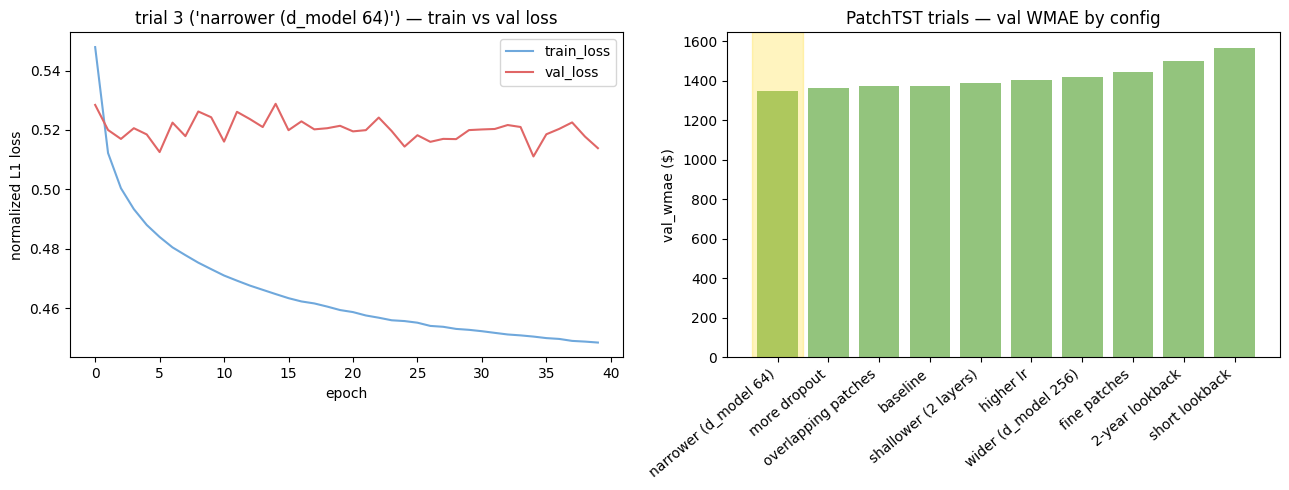

In [9]:
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(tracker._history[best_id])
summary = tracker.summary().sort_values("val_wmae").reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss", color="#6fa8dc")
if "val_loss" in hist_df:
    ax.plot(hist_df["epoch"], hist_df["val_loss"], label="val_loss", color="#e06666")
ax.set_xlabel("epoch")
ax.set_ylabel("normalized L1 loss")
ax.set_title(f"trial {best_id} ('{tracker._notes.get(best_id, '')}') \u2014 train vs val loss")
ax.legend()

ax2 = axes[1]
x = np.arange(len(summary))
ax2.bar(x, summary["val_wmae"], color="#93c47d")
ax2.axvspan(-0.5, 0.5, color="gold", alpha=0.25)  # summary sorted asc -> index 0 = best
ax2.set_xticks(x)
ax2.set_xticklabels(summary["note"], rotation=40, ha="right")
ax2.set_ylabel("val_wmae ($)")
ax2.set_title("PatchTST trials \u2014 val WMAE by config")

plt.tight_layout()
plt.savefig("/kaggle/working/patchtst_trainvsval.png", dpi=150)
plt.show()


## 6 · Kaggle submission (best config, final iteration only)

The comparison is on the 8-week holdout. The real test set is a **39-week**
future horizon, so a submission retrains the **best** config on **all** labelled
data with `pred_len = 39` and forecasts forward. Flip `RUN_SUBMISSION` on only
for the final run.

In [10]:
RUN_SUBMISSION = True
FINAL_CFG = TRIAL_CFGS[int(tracker.summary().iloc[0]["trial"])]
print("submission uses best cfg (trial %d):" % int(tracker.summary().iloc[0]["trial"]), FINAL_CFG)

if RUN_SUBMISSION:
    H = len(store.test_dates)
    set_seed(FINAL_CFG["seed"])
    Xf, Yf = store.make_full_windows(FINAL_CFG["input_len"], H)
    sub_model, _ = train_torch(build_model(FINAL_CFG, pred_len=H), Xf, Yf,
                            FINAL_CFG["lr"], FINAL_CFG["epochs"], FINAL_CFG["batch_size"])
    Xi, keys, mus, sds = store.make_forecast_inputs(FINAL_CFG["input_len"])
    sub_model.eval()
    with torch.no_grad():
        pf = sub_model(torch.tensor(Xi).to(DEVICE)).cpu().numpy()
    pbk = {k: pf[i] * sds[i] + mus[i] for i, k in enumerate(keys)}
    for k in store.series:
        pbk.setdefault(k, store.naive_submit(k))
    submission = C.build_submission(panel, store, pbk)
    submission.to_csv("submission.csv", index=False)
    print("wrote submission.csv:", submission.shape)
    display(submission.head())

    # ---- log the final iteration to MLflow (best cfg + submission + model) --
    best_row = tracker.summary().iloc[0]
    torch.save(sub_model.state_dict(), "/kaggle/working/patchtst_best.pt")
    tracker.log_artifacts_run(
        "patchtst_Best",
        params={**FINAL_CFG, "submission_horizon": H},
        metrics={m: float(best_row[m]) for m in
                 ["val_wmae", "val_mae", "val_rmse", "val_r2", "train_wmae", "train_mae"]
                 if m in best_row.index},
        artifacts=["submission.csv", "/kaggle/working/patchtst_best.pt",
                   "/kaggle/working/patchtst_experiments.csv",
                   "/kaggle/working/patchtst_trainvsval.png"],
        texts={"model_summary.txt": str(build_model(FINAL_CFG, pred_len=H))})

submission uses best cfg (trial 3): {'input_len': 52, 'pred_len': 8, 'epochs': 40, 'lr': 0.001, 'batch_size': 512, 'seed': 42, 'patch_len': 13, 'stride': 13, 'd_model': 64, 'n_heads': 8, 'depth': 3, 'd_ff': 256, 'dropout': 0.1}
wrote submission.csv: (115064, 2)


,Id,Weekly_Sales
0,1_1_2012-11-02,38579.1797
1,1_1_2012-11-09,22235.6289
2,1_1_2012-11-16,20130.8242
3,1_1_2012-11-23,21020.5059
4,1_1_2012-11-30,24530.1973


🏃 View run patchtst_Best at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/2/runs/d366d7c3a14f4ef8b718e8225b05c5d3
🧪 View experiment at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/2
[patchtst] logged final artifacts run 'patchtst_Best'


### 6b · Actual vs Predicted (held-out val, best config)

Held-out `(y_true, y_pred)` pairs only exist transiently inside `run_trial()` and
aren't kept after a trial finishes, so this re-fits **only the winning
`FINAL_CFG`** — one extra run, not a relog of the sweep (`tracker=None`, nothing
gets written to the tracker or MLflow). Same seed as the original trial, so
`val_wmae` below should reproduce the leaderboard number as a sanity check.

val_wmae (should match leaderboard): 1347.7


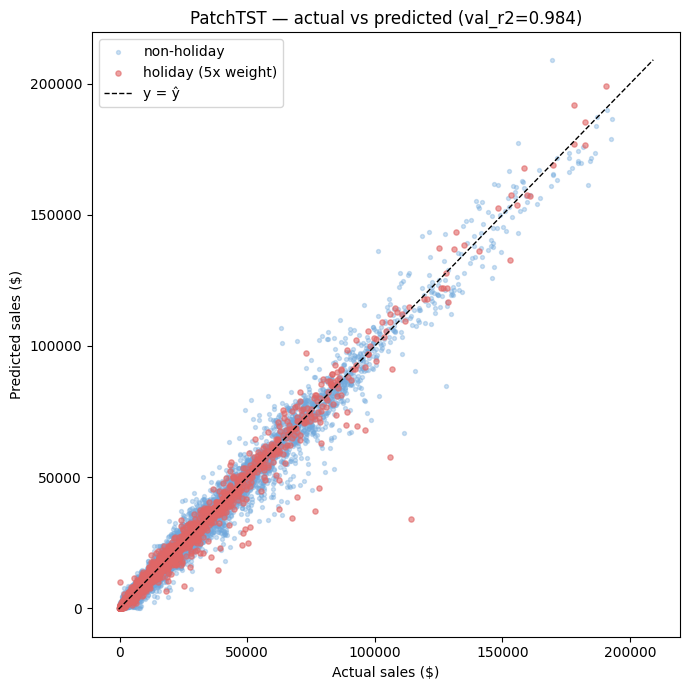

largest residual: 80382.3 -> row:


,Store,Dept,Date,IsHoliday,y_true,y_pred
6611,13,3,2012-09-07,1.0000,114230.6000,33848.3047


In [13]:
plot_metrics, plot_merged = run_trial(FINAL_CFG, tracker=None, note="best_for_plot",
                                      return_predictions=True)
print("val_wmae (should match leaderboard):", plot_metrics["val_wmae"])

fig, ax = plt.subplots(figsize=(7, 7))
is_hol = plot_merged["IsHoliday"].astype(bool)
ax.scatter(plot_merged.loc[~is_hol, "y_true"], plot_merged.loc[~is_hol, "y_pred"],
           s=8, alpha=0.35, color="#6fa8dc", label="non-holiday")
ax.scatter(plot_merged.loc[is_hol, "y_true"], plot_merged.loc[is_hol, "y_pred"],
           s=14, alpha=0.6, color="#e06666", label="holiday (5x weight)")

lo = min(plot_merged["y_true"].min(), plot_merged["y_pred"].min())
hi = max(plot_merged["y_true"].max(), plot_merged["y_pred"].max())
ax.plot([lo, hi], [lo, hi], color="black", linewidth=1, linestyle="--", label="y = \u0177")

ax.set_xlabel("Actual sales ($)")
ax.set_ylabel("Predicted sales ($)")
ax.set_title(f"PatchTST \u2014 actual vs predicted (val_r2={plot_metrics['val_r2']:.3f})")
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/patchtst_actualvspredicted.png", dpi=150)
plt.show()

resid = (plot_merged["y_pred"] - plot_merged["y_true"]).abs()
worst = plot_merged.loc[[resid.idxmax()]]
print("largest residual:", round(resid.max(), 2), "-> row:")
display(worst)
